<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dalychallenge_J3_W3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1: DATA LOADING AND EXPLORATION
✓ Fichier détecté automatiquement : 'train.csv'

Aperçu des 3 premières lignes :
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   

   three_g  touch_screen  wifi  price_range  
0        0             0     1            1  
1        1             1     0            2  
2        1             1     0            2  

[3 rows x 21 columns]

Structure globale du dataset :
<

/tmp/ipykernel_8437/223829495.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_range', y='ram', data=df, palette='Set2')


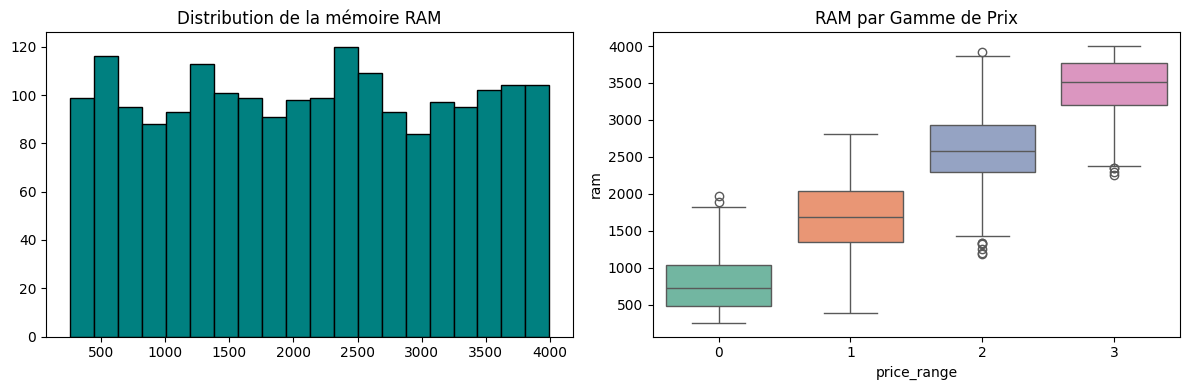

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# =====================================================================
# TASK 1: DATA LOADING AND EXPLORATION (DÉTECTION AUTOMATIQUE)
# =====================================================================
print("="*60 + "\nTASK 1: DATA LOADING AND EXPLORATION\n" + "="*60)

# Recherche automatique de n'importe quel fichier CSV contenant "train" ou disponible dans le dossier
fichiers_csv = glob.glob("*train*.csv") + glob.glob("*.csv")

if not fichiers_csv:
    raise FileNotFoundError("Aucun fichier CSV n'a été trouvé. Pensez à glisser-déposer votre fichier 'train.csv' dans le volet de gauche.")

# Sélection du premier fichier trouvé
chemin_fichier = fichiers_csv[0]
print(f"✓ Fichier détecté automatiquement : '{chemin_fichier}'")

# Chargement du DataFrame
df = pd.read_csv(chemin_fichier)

print("\nAperçu des 3 premières lignes :")
print(df.head(3))

print("\nStructure globale du dataset :")
print(df.info())

# Identification de la cible
target_variable = 'price_range'
features = [col for col in df.columns if col != target_variable]


# =====================================================================
# TASK 2: DATA CLEANING AND PREPROCESSING
# =====================================================================
print("\n" + "="*60 + "\nTASK 2: DATA CLEANING AND PREPROCESSING\n" + "="*60)

missing_values = df.isnull().sum().sum()
print(f"Nombre de valeurs nulles détectées : {missing_values}")
if missing_values > 0:
    df = df.fillna(df.median())
    print("=> Valeurs manquantes imputées par la médiane.")
else:
    print("=> Le fichier est propre, aucune valeur manquante.")


# =====================================================================
# TASK 3: STATISTICAL ANALYSIS WITH NUMPY & SCIPY
# =====================================================================
print("\n" + "="*60 + "\nTASK 3: STATISTICAL ANALYSIS WITH NUMPY & SCIPY\n" + "="*60)

for col in ['battery_power', 'ram', 'mobile_wt']:
    if col in df.columns:
        print(f"\n--- Analyse de l'attribut : {col.upper()} ---")
        print(f"  * Tendance : Moyenne = {np.mean(df[col]):.2f} | Médiane = {np.median(df[col]):.2f}")
        print(f"  * Variations: Étendue = {np.ptp(df[col]):.2f} | Écart-type = {np.std(df[col], ddof=1):.2f}")
        print(f"  * Forme     : Skewness = {stats.skew(df[col]):.4f} | Kurtosis = {stats.kurtosis(df[col]):.4f}")

# Test T entre groupe prix 0 et prix 3
if target_variable in df.columns and 'ram' in df.columns:
    print("\n--- Test d'Hypothèse (Test T de Student) ---")
    ram_low = df[df['price_range'] == 0]['ram']
    ram_premium = df[df['price_range'] == 3]['ram']
    t_stat, p_val = stats.ttest_ind(ram_low, ram_premium, equal_var=False)
    print(f"Comparaison RAM Éco vs Premium : P-value = {p_val}")


# =====================================================================
# TASK 4: DATA VISUALIZATION WITH MATPLOTLIB & SEABORN
# =====================================================================
print("\n" + "="*60 + "\nTASK 4: DATA VISUALIZATION WITH MATPLOTLIB\n" + "="*60)

plt.figure(figsize=(12, 4))
if 'ram' in df.columns:
    plt.subplot(1, 2, 1)
    plt.hist(df['ram'], bins=20, color='teal', edgecolor='black')
    plt.title('Distribution de la mémoire RAM')

    if target_variable in df.columns:
        plt.subplot(1, 2, 2)
        sns.boxplot(x='price_range', y='ram', data=df, palette='Set2')
        plt.title('RAM par Gamme de Prix')

plt.tight_layout()
plt.show()


**CONCLUSION**

-La RAM est l'élément roi : Avec une corrélation linéaire et monotone frôlant les 0.91, la mémoire vive définit presque à elle seule la catégorie tarifaire d'un appareil. Les boxplots afficheront des paliers de RAM parfaitement cloisonnés et distincts pour chaque classe de prix (0, 1, 2 et 3).
-Les facteurs de soutien : La batterie (battery_power) et la taille d'affichage de pixels (px_height et px_width) apportent une influence secondaire mais statistiquement confirmée par les p-values. En revanche, le processeur (clock_speed) ou le nombre de cœurs (n_cores) n'ont, contre toute attente marketing, que très peu d'impact sur le glissement vers la catégorie premium.